In [1]:
# This is timport datarobot as dr
import pandas as pd
import numpy as np
from datetime import datetime
from scipy.stats import mode
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import sys, os
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

# Go up one directory from "notebooks" to project root
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(project_root)

from scripts.modeling import (rank_models,
                              split_dataset,
                                plot_roc_curve_from_df) 




In [2]:
# import sys
# print(sys.executable)

# !{sys.executable} -m pip install lightgbm

In [3]:
# import sys
# print(sys.executable)

# !{sys.executable} -m pip install xgboost

# 1 Ingests Data 

In [4]:
# Build base directory (go up one level from current /02_scripts)
base_dir = os.path.dirname(os.getcwd())   # → c:\Users\linoc\OneDrive\Encoder\03_partos
base_dir_raw =  Path(base_dir)
base_dir_raw= str(base_dir_raw.parents[1])

In [5]:
# Build the path to the target CSV
csv_path_Modulo1631_REC91_2024_M_clear = os.path.join(base_dir,"data\\interim", "Modulo1631_REC91_2024_M_clear.csv")
csv_path_Modulo1635_RE516171_2024_M_clear = os.path.join(base_dir,"data\\interim", "Modulo1635_RE516171_2024_M_clear.csv")
csv_path_Modulo1632_RE223132_2024_M_clear = os.path.join(base_dir,"data\\interim", "Modulo1632_RE223132_2024_M_clear.csv")
csv_path_Modulo1633_REC41_2024_fil_clear_v2 = os.path.join(base_dir,"data\\interim", "Modulo1633_REC41_2024_fil_clear_v2.csv")
csv_path_Modulo1633_REC94_2024_fil_clear_v2 = os.path.join(base_dir,"data\\interim", "Modulo1633_REC94_2024_fil_clear_v2.csv")
csv_path_Modulo1640_CSALUD01_2024_M_clear = os.path.join(base_dir,"data\\interim", "Modulo1640_CSALUD01_2024_M_clear.csv")
csv_path_target_final = os.path.join(base_dir,"data\\interim", "target_final.csv")

# Load the CSV into a DataFrame
Modulo1631_REC91_2024_M_clear = pd.read_csv(csv_path_Modulo1631_REC91_2024_M_clear, low_memory=False)
Modulo1635_RE516171_2024_M_clear= pd.read_csv(csv_path_Modulo1635_RE516171_2024_M_clear, low_memory=False)
Modulo1632_RE223132_2024_M_clear= pd.read_csv(csv_path_Modulo1632_RE223132_2024_M_clear, low_memory=False)
Modulo1633_REC41_2024_fil_clear_v2= pd.read_csv(csv_path_Modulo1633_REC41_2024_fil_clear_v2, low_memory=False)
Modulo1633_REC94_2024_fil_clear_v2= pd.read_csv(csv_path_Modulo1633_REC94_2024_fil_clear_v2, low_memory=False)
Modulo1640_CSALUD01_2024_M_clear= pd.read_csv(csv_path_Modulo1640_CSALUD01_2024_M_clear, low_memory=False)
target_final = pd.read_csv(csv_path_target_final, low_memory=False)


print(Modulo1631_REC91_2024_M_clear.shape)
print(Modulo1635_RE516171_2024_M_clear.shape)
print(Modulo1632_RE223132_2024_M_clear.shape)
print(Modulo1633_REC41_2024_fil_clear_v2.shape)
print(Modulo1633_REC94_2024_fil_clear_v2.shape) 
print(Modulo1640_CSALUD01_2024_M_clear.shape) 
print(target_final.shape) 

(37117, 132)
(34252, 63)
(34252, 65)
(16983, 463)
(16983, 280)
(34018, 153)
(18335, 5)


In [6]:
Modulo1633_REC41_2024_fil_clear_v2.info(verbose=True, show_counts=True    
                                  )

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16983 entries, 0 to 16982
Data columns (total 463 columns):
 #    Column          Non-Null Count  Dtype  
---   ------          --------------  -----  
 0    BIDX_x          16983 non-null  float64
 1    M6              16983 non-null  float64
 2    M7              16983 non-null  float64
 3    M8              16983 non-null  float64
 4    M9              16983 non-null  float64
 5    M11             16983 non-null  float64
 6    M13             16983 non-null  float64
 7    M14             16983 non-null  float64
 8    premature_flag  16983 non-null  int64  
 9    M2A             16983 non-null  float64
 10   M2B             16983 non-null  float64
 11   M2C             16983 non-null  float64
 12   M2D             16983 non-null  float64
 13   M2E             16983 non-null  float64
 14   M2G             16983 non-null  float64
 15   M2K             16983 non-null  float64
 16   M2N             16983 non-null  float64
 17   M3A       

In [7]:
target_final.head()

,CASEID,BIDX,Q220A,premature,premature_flag
0,325503101 2,1,7,1,1
1,325504701 2,1,9,0,0
2,325505001 1,1,9,0,0
3,325508901 2,1,9,0,0
4,325509701 2,1,9,0,0


In [8]:
RANK_Modulo1631_REC91_2024_M_clear = ['SREGION','CASEID',
'S108N',
'S119',
'S119D',
'S704N',
'S816W',
'S816G',
'S816B',
'S816AL',
'S500B',
# 'S229A1',
# 'S229Y',
# 'S229A'
]

RANK_Modulo1635_RE516171_2024_M_clear =['CASEID',
    'V704',
'V715',
'V501',
'V716',
'V511',
'V631',
'V732',
'V504',
'V743F',
'V531',
'V525',
'V717',
'V743E',
'V743A',
'V702',
'V721',
'V705',

]
RANK_Modulo1632_RE223132_2024_M_clear = ['CASEID',
    'V212',
'V228',
'V218',
'V208',
'V217',
'V364',

]

RANK_Modulo1633_REC41_2024_fil_v2 =['CASEID',
    'M14',
'M13',
'M17',
'M1',
'M18',
'M19',
'M19A',
'M2C',
'M3C',
'M3G',
'M42A',
'M42B',
'M42C',
'M42D',
'M42E',
'M43',
'M44',
'M45',
'M46',
'M47',
'M48',
'M49A',
'M49B',
'M49C',
'M49D',
'M49X',
'M49Z',
'M57A',
'M57B',
'M60',
'M3A',
'M57I',
'M3H',
'M57O',
'M57G',
'M3B',
'M57M',
'M57K',
'M57X',
'M2B',
'M57Q',
'M57E',

]
RANK_Modulo1633_REC94_2024_fil_clear_v2 = ['CASEID',
'S410B',
'S411B',
'S411F',
'S411G',
'S411H',
'S411I',
'S411J',
'S411K',
'QI422A_A',
'QI422A_B',
'QI422A_C',
'QI422A_D',
'S426E',
'S426GE',
'S411BA',
'S413',
'S441',
'S411DA',
'S411EA',
'S411CA',
'S422I',


]
RANK_Modulo1640_CSALUD01_2024_M_clear =['HHID',
    'QS25N',
'QS22A',
'QS27_A',
'QS102',
'QS27_B',
'QS207C',
'QS109',
'QS27_BD',
'QS25AA',
'QS25BB',
'QS406',
'QS100',
#'QS103U',
'QS107',
# 'QS110U',
# 'QS202',
# 'QS203U',
# 'QS204C',
# 'QS205U',
'QS206',
'QS27_D',
'QS27_BC',
'QS25A',
'QS27_E',
'QS27_ ',
'QS25C5',
'QS25C3',

]

In [9]:
Modulo1631_REC91_2024_M_clear[RANK_Modulo1631_REC91_2024_M_clear].head()

,SREGION,CASEID,S108N,S119,S119D,S704N,S816W,S816G,S816B,S816AL,S500B
0,0.666667,325503101 2,0.4,1.0,0.061856,0.2,0,0,0,0,0
1,0.666667,325503101 4,0.4,1.0,0.061856,0.4,0,0,0,0,0
2,0.666667,325503901 2,0.4,1.0,0.061856,0.4,0,0,1,0,0
3,0.666667,325504701 2,0.4,1.0,0.061856,0.4,0,0,0,0,0
4,0.666667,325505001 1,0.2,1.0,0.061856,0.2,0,0,0,0,0


In [10]:
Modulo1635_RE516171_2024_M_clear[RANK_Modulo1635_RE516171_2024_M_clear].head()

,CASEID,V704,V715,V501,V716,V511,V631,V732,V504,V743F,V531,V525,V717,V743E,V743A,V702,V721,V705
0,325503101 2,0.876289,0.352941,0.4,0.589474,0.461538,0.333333,0.0,0.0,0.333333,0.607143,0.607143,0.0,0.2,0.25,1.000000,1.0,0.888889
1,325503101 4,0.618557,0.647059,0.0,0.589474,0.346154,0.000000,0.0,0.0,0.333333,0.000000,0.000000,0.0,0.2,0.25,0.833333,1.0,0.444444
2,325503901 2,0.618557,0.647059,0.0,0.589474,0.346154,0.000000,0.0,0.0,0.333333,0.000000,0.000000,0.0,0.2,0.25,0.833333,1.0,0.444444
3,325504701 2,0.969072,0.647059,0.4,0.589474,0.423077,0.000000,0.0,0.0,0.333333,0.642857,0.642857,0.0,0.4,0.25,0.833333,1.0,0.666667
4,325505001 1,0.793814,0.352941,0.4,0.589474,0.230769,0.666667,0.0,0.0,0.000000,0.571429,0.571429,0.0,0.2,0.50,1.000000,1.0,0.888889


In [11]:
Modulo1632_RE223132_2024_M_clear[RANK_Modulo1632_RE223132_2024_M_clear].head()

,CASEID,V212,V228,V218,V208,V217,V364
0,325503101 2,0.44,0,0.285714,0.5,0.285714,0.333333
1,325503101 4,0.36,0,0.000000,0.0,1.000000,0.666667
2,325503901 2,0.36,0,0.000000,0.0,0.714286,0.666667
3,325504701 2,0.36,0,0.285714,0.5,1.000000,0.333333
4,325505001 1,0.24,0,0.285714,0.5,0.571429,0.000000


In [12]:
# keep all columns where name contains any of the patterns
pattern = '|'.join([f'^{x}' for x in RANK_Modulo1633_REC41_2024_fil_v2])  # start-with pattern
# Add rule for exact match 'MIDX'
pattern = f'({pattern})|(^MIDX$)'
Modulo1633_REC41_2024_fil_clear_v2 = Modulo1633_REC41_2024_fil_clear_v2.filter(regex=pattern, axis=1)
Modulo1633_REC41_2024_fil_clear_v2.info(verbose = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16983 entries, 0 to 16982
Data columns (total 146 columns):
 #    Column     Dtype  
---   ------     -----  
 0    M11        float64
 1    M13        float64
 2    M14        float64
 3    M2B        float64
 4    M2C        float64
 5    M3A        int64  
 6    M3B        int64  
 7    M3C        int64  
 8    M3G        int64  
 9    M3H        int64  
 10   M17        int64  
 11   M57E       float64
 12   M57G       float64
 13   M57I       float64
 14   M57K       float64
 15   M57M       float64
 16   M57O       float64
 17   M57Q       float64
 18   M57X       float64
 19   M1_0       int64  
 20   M1_1       int64  
 21   M1_2       int64  
 22   M1_3       int64  
 23   M1_4       int64  
 24   M1_5       int64  
 25   M1_7       int64  
 26   M1_8       int64  
 27   M1_<NA>    int64  
 28   M1A_0      int64  
 29   M1A_1      int64  
 30   M1A_2      int64  
 31   M1A_3      int64  
 32   M1A_4      int64  
 33   M1A_5    

In [13]:
# keep all columns where name contains any of the patterns
pattern = '|'.join([f'^{x}' for x in RANK_Modulo1633_REC94_2024_fil_clear_v2])  # start-with pattern
Modulo1633_REC94_2024_fil_clear_v2_filter = Modulo1633_REC94_2024_fil_clear_v2.filter(regex=pattern, axis=1)
Modulo1633_REC94_2024_fil_clear_v2_filter.info(verbose = True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16983 entries, 0 to 16982
Data columns (total 136 columns):
 #    Column         Dtype  
---   ------         -----  
 0    S411DA         float64
 1    S411CA         float64
 2    S422I          float64
 3    S411EA         float64
 4    S411BA         float64
 5    S413           float64
 6    S426E          float64
 7    S426GE         float64
 8    S441           int64  
 9    S410B_1        int64  
 10   S410B_2        int64  
 11   S410B_3        int64  
 12   S410B_4        int64  
 13   S410B_5        int64  
 14   S410B_6        int64  
 15   S410B_7        int64  
 16   S410B_8        int64  
 17   S410B_9        int64  
 18   S410B_98       int64  
 19   S410B_<NA>     int64  
 20   S411B_0        int64  
 21   S411B_1        int64  
 22   S411B_8        int64  
 23   S411B_<NA>     int64  
 24   S411F_0        int64  
 25   S411F_1        int64  
 26   S411F_8        int64  
 27   S411F_<NA>     int64  
 28   S411G_0       

In [14]:
Modulo1640_CSALUD01_2024_M_clear[RANK_Modulo1640_CSALUD01_2024_M_clear].head()

,HHID,QS25N,QS22A,QS27_A,QS102,QS27_B,QS207C,QS109,QS27_BD,QS25AA,...,QS100,QS107,QS206,QS27_D,QS27_BC,QS25A,QS27_E,QS27_,QS25C5,QS25C3
0,325503101,0.4,0.729412,1,1.0,0,0.342857,1.0,0,1.000000,...,1.0,1.0,0.0,0,0,1.0,0,0,1.0,1.0
1,325503901,0.4,0.964706,0,1.0,1,0.371429,1.0,0,1.000000,...,0.0,0.0,1.0,0,0,1.0,0,0,1.0,1.0
2,325504001,0.4,0.400000,1,1.0,0,0.371429,1.0,0,1.000000,...,0.0,1.0,1.0,0,0,0.8,0,0,1.0,1.0
3,325504701,0.4,0.776471,1,1.0,0,0.342857,1.0,0,1.000000,...,0.0,0.0,0.0,0,0,1.0,0,0,1.0,1.0
4,325505001,0.2,0.811765,1,1.0,0,0.457143,1.0,0,0.888889,...,1.0,1.0,0.0,0,0,0.8,0,0,1.0,1.0


# 2 Consolidate Datasets

In [15]:
target_final.CASEID.nunique()

18335

In [16]:
data_train = target_final.merge(Modulo1631_REC91_2024_M_clear[RANK_Modulo1631_REC91_2024_M_clear].rename(
    columns={col: f"REC91_{col}" if col not in ["CASEID"] else col for col in Modulo1631_REC91_2024_M_clear[RANK_Modulo1631_REC91_2024_M_clear].columns}),
                                 on='CASEID', 
                                 how='left')
data_train.CASEID.nunique()

18335

In [17]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18335 entries, 0 to 18334
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CASEID          18335 non-null  object 
 1   BIDX            18335 non-null  int64  
 2   Q220A           18335 non-null  int64  
 3   premature       18335 non-null  int64  
 4   premature_flag  18335 non-null  int64  
 5   REC91_SREGION   18335 non-null  float64
 6   REC91_S108N     18335 non-null  float64
 7   REC91_S119      18335 non-null  float64
 8   REC91_S119D     18335 non-null  float64
 9   REC91_S704N     18335 non-null  float64
 10  REC91_S816W     18335 non-null  int64  
 11  REC91_S816G     18335 non-null  int64  
 12  REC91_S816B     18335 non-null  int64  
 13  REC91_S816AL    18335 non-null  int64  
 14  REC91_S500B     18335 non-null  int64  
dtypes: float64(5), int64(9), object(1)
memory usage: 2.1+ MB


In [18]:
data_train = data_train.merge(Modulo1635_RE516171_2024_M_clear[RANK_Modulo1635_RE516171_2024_M_clear].rename(
    columns={col: f"RE516171_{col}" if col not in ["CASEID"] else col for col in Modulo1635_RE516171_2024_M_clear[RANK_Modulo1635_RE516171_2024_M_clear].columns}),
                                 on='CASEID', 
                                 how='left')
data_train.CASEID.nunique()


18335

In [19]:
data_train.info(verbose = True,show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18335 entries, 0 to 18334
Data columns (total 32 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CASEID          18335 non-null  object 
 1   BIDX            18335 non-null  int64  
 2   Q220A           18335 non-null  int64  
 3   premature       18335 non-null  int64  
 4   premature_flag  18335 non-null  int64  
 5   REC91_SREGION   18335 non-null  float64
 6   REC91_S108N     18335 non-null  float64
 7   REC91_S119      18335 non-null  float64
 8   REC91_S119D     18335 non-null  float64
 9   REC91_S704N     18335 non-null  float64
 10  REC91_S816W     18335 non-null  int64  
 11  REC91_S816G     18335 non-null  int64  
 12  REC91_S816B     18335 non-null  int64  
 13  REC91_S816AL    18335 non-null  int64  
 14  REC91_S500B     18335 non-null  int64  
 15  RE516171_V704   18335 non-null  float64
 16  RE516171_V715   18335 non-null  float64
 17  RE516171_V501   18335 non-null 

In [20]:
Modulo1633_REC41_2024_fil_clear_v2.info(verbose=True, show_counts=True    )

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16983 entries, 0 to 16982
Data columns (total 146 columns):
 #    Column     Non-Null Count  Dtype  
---   ------     --------------  -----  
 0    M11        16983 non-null  float64
 1    M13        16983 non-null  float64
 2    M14        16983 non-null  float64
 3    M2B        16983 non-null  float64
 4    M2C        16983 non-null  float64
 5    M3A        16983 non-null  int64  
 6    M3B        16983 non-null  int64  
 7    M3C        16983 non-null  int64  
 8    M3G        16983 non-null  int64  
 9    M3H        16983 non-null  int64  
 10   M17        16983 non-null  int64  
 11   M57E       16983 non-null  float64
 12   M57G       16983 non-null  float64
 13   M57I       16983 non-null  float64
 14   M57K       16983 non-null  float64
 15   M57M       16983 non-null  float64
 16   M57O       16983 non-null  float64
 17   M57Q       16983 non-null  float64
 18   M57X       16983 non-null  float64
 19   M1_0       16983 non-nu

In [21]:
# keep all columns where name contains any of the patterns
pattern = '|'.join([f'^{x}' for x in RANK_Modulo1633_REC41_2024_fil_v2])  # start-with pattern
Modulo1633_REC41_2024_fil_clear_v2_filter = Modulo1633_REC41_2024_fil_clear_v2.filter(regex=pattern, axis=1)
Modulo1633_REC41_2024_fil_clear_v2_filter.info(verbose = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16983 entries, 0 to 16982
Data columns (total 146 columns):
 #    Column     Dtype  
---   ------     -----  
 0    M11        float64
 1    M13        float64
 2    M14        float64
 3    M2B        float64
 4    M2C        float64
 5    M3A        int64  
 6    M3B        int64  
 7    M3C        int64  
 8    M3G        int64  
 9    M3H        int64  
 10   M17        int64  
 11   M57E       float64
 12   M57G       float64
 13   M57I       float64
 14   M57K       float64
 15   M57M       float64
 16   M57O       float64
 17   M57Q       float64
 18   M57X       float64
 19   M1_0       int64  
 20   M1_1       int64  
 21   M1_2       int64  
 22   M1_3       int64  
 23   M1_4       int64  
 24   M1_5       int64  
 25   M1_7       int64  
 26   M1_8       int64  
 27   M1_<NA>    int64  
 28   M1A_0      int64  
 29   M1A_1      int64  
 30   M1A_2      int64  
 31   M1A_3      int64  
 32   M1A_4      int64  
 33   M1A_5    

In [22]:
data_train = data_train.merge(Modulo1633_REC41_2024_fil_clear_v2_filter.rename(
    columns={col: f"REC41_{col}" if col not in ["CASEID"] else col for col in Modulo1633_REC41_2024_fil_clear_v2_filter.columns}),
                                 on='CASEID', 
                                 how='left')
data_train.CASEID.nunique()

18335

In [23]:
Modulo1633_REC94_2024_fil_clear_v2.info(verbose = True,show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16983 entries, 0 to 16982
Data columns (total 280 columns):
 #    Column            Non-Null Count  Dtype  
---   ------            --------------  -----  
 0    IDX94_x           16983 non-null  float64
 1    S411DA            16983 non-null  float64
 2    S411CA            16983 non-null  float64
 3    S422I             16983 non-null  float64
 4    S411EA            16983 non-null  float64
 5    S411BA            16983 non-null  float64
 6    IDX94_y           16983 non-null  float64
 7    premature_flag_x  16983 non-null  int64  
 8    premature_flag_y  16983 non-null  int64  
 9    S413              16983 non-null  float64
 10   S426E             16983 non-null  float64
 11   S426GA            16983 non-null  float64
 12   S426GB            16983 non-null  float64
 13   S426GC            16983 non-null  float64
 14   S426GD            16983 non-null  float64
 15   S426GE            16983 non-null  float64
 16   S430D             16

In [24]:
# Modulo1633_REC94_2024_fil_clear_v2.drop(['Q220A',
#                                          'BIDX',
#                                          'IDX94_x',
#                                          'IDX94_y',
#                                          'premature_flag_x',
#                                          'premature_flag_y',
#                                          'BIDX_x_1','BIDX_x_2','BIDX_x_3','BIDX_x_4','BIDX_x_5','',''])

# keep all columns where name contains any of the patterns
pattern = '|'.join([f'^{x}' for x in RANK_Modulo1633_REC94_2024_fil_clear_v2])  # start-with pattern
Modulo1633_REC94_2024_fil_clear_v2_filter = Modulo1633_REC94_2024_fil_clear_v2.filter(regex=pattern, axis=1)
Modulo1633_REC94_2024_fil_clear_v2_filter.info(verbose = True)

data_train = data_train.merge(Modulo1633_REC94_2024_fil_clear_v2_filter.rename(
    columns={col: f"REC94_{col}" if col not in ["CASEID"] else col for col in Modulo1633_REC94_2024_fil_clear_v2_filter.columns}),
                                 on='CASEID', 
                                 how='left')
data_train.CASEID.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16983 entries, 0 to 16982
Data columns (total 136 columns):
 #    Column         Dtype  
---   ------         -----  
 0    S411DA         float64
 1    S411CA         float64
 2    S422I          float64
 3    S411EA         float64
 4    S411BA         float64
 5    S413           float64
 6    S426E          float64
 7    S426GE         float64
 8    S441           int64  
 9    S410B_1        int64  
 10   S410B_2        int64  
 11   S410B_3        int64  
 12   S410B_4        int64  
 13   S410B_5        int64  
 14   S410B_6        int64  
 15   S410B_7        int64  
 16   S410B_8        int64  
 17   S410B_9        int64  
 18   S410B_98       int64  
 19   S410B_<NA>     int64  
 20   S411B_0        int64  
 21   S411B_1        int64  
 22   S411B_8        int64  
 23   S411B_<NA>     int64  
 24   S411F_0        int64  
 25   S411F_1        int64  
 26   S411F_8        int64  
 27   S411F_<NA>     int64  
 28   S411G_0       

18335

In [25]:
data_train.info(verbose = True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18335 entries, 0 to 18334
Data columns (total 312 columns):
 #    Column               Non-Null Count  Dtype  
---   ------               --------------  -----  
 0    CASEID               18335 non-null  object 
 1    BIDX                 18335 non-null  int64  
 2    Q220A                18335 non-null  int64  
 3    premature            18335 non-null  int64  
 4    premature_flag       18335 non-null  int64  
 5    REC91_SREGION        18335 non-null  float64
 6    REC91_S108N          18335 non-null  float64
 7    REC91_S119           18335 non-null  float64
 8    REC91_S119D          18335 non-null  float64
 9    REC91_S704N          18335 non-null  float64
 10   REC91_S816W          18335 non-null  int64  
 11   REC91_S816G          18335 non-null  int64  
 12   REC91_S816B          18335 non-null  int64  
 13   REC91_S816AL         18335 non-null  int64  
 14   REC91_S500B          18335 non-null  int64  
 15   RE516171_V704    

In [26]:
Modulo1640_CSALUD01_2024_M_clear.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34018 entries, 0 to 34017
Data columns (total 153 columns):
 #    Column       Non-Null Count  Dtype  
---   ------       --------------  -----  
 0    ID1          34018 non-null  float64
 1    QHCLUSTER    34018 non-null  float64
 2    QHNUMBER     34018 non-null  float64
 3    QHHOME       34018 non-null  float64
 4    QSNUMERO     34018 non-null  float64
 5    QSINTM       34018 non-null  float64
 6    QSINTY       34018 non-null  float64
 7    QSTOTVISIT   34018 non-null  float64
 8    QSRESULT     34018 non-null  float64
 9    QSRESINF     34018 non-null  float64
 10   QS20C        34018 non-null  float64
 11   QSSEXO       34018 non-null  float64
 12   QSMEF        34018 non-null  float64
 13   QSDIA        34018 non-null  float64
 14   QS22M        34018 non-null  float64
 15   QS22A        34018 non-null  float64
 16   QS23         34018 non-null  float64
 17   QS24         34018 non-null  float64
 18   QS25N        34018 non-n

In [27]:
data_train.head()

,CASEID,BIDX,Q220A,premature,premature_flag,REC91_SREGION,REC91_S108N,REC91_S119,REC91_S119D,REC91_S704N,...,REC94_QI422A_B_2,REC94_QI422A_B_8,REC94_QI422A_B_<NA>,REC94_QI422A_C_1,REC94_QI422A_C_2,REC94_QI422A_C_8,REC94_QI422A_C_<NA>,REC94_QI422A_D_1,REC94_QI422A_D_2,REC94_QI422A_D_<NA>
0,325503101 2,1,7,1,1,0.666667,0.4,1.0,0.061856,0.2,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,325504701 2,1,9,0,0,0.666667,0.4,1.0,0.061856,0.4,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,325505001 1,1,9,0,0,0.666667,0.2,1.0,0.061856,0.2,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,325508901 2,1,9,0,0,0.666667,0.4,1.0,1.000000,0.4,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,325509701 2,1,9,0,0,0.666667,0.6,1.0,0.061856,0.8,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [28]:
# Clean CASEID to keep only the first numeric part before space
data_train['CASEID_HHID'] = data_train['CASEID'].astype(str).str.split().str[0]
data_train['CASEID_HHID'] = data_train['CASEID_HHID'].astype(int)

data_train.head()

,CASEID,BIDX,Q220A,premature,premature_flag,REC91_SREGION,REC91_S108N,REC91_S119,REC91_S119D,REC91_S704N,...,REC94_QI422A_B_8,REC94_QI422A_B_<NA>,REC94_QI422A_C_1,REC94_QI422A_C_2,REC94_QI422A_C_8,REC94_QI422A_C_<NA>,REC94_QI422A_D_1,REC94_QI422A_D_2,REC94_QI422A_D_<NA>,CASEID_HHID
0,325503101 2,1,7,1,1,0.666667,0.4,1.0,0.061856,0.2,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,325503101
1,325504701 2,1,9,0,0,0.666667,0.4,1.0,0.061856,0.4,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,325504701
2,325505001 1,1,9,0,0,0.666667,0.2,1.0,0.061856,0.2,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,325505001
3,325508901 2,1,9,0,0,0.666667,0.4,1.0,1.000000,0.4,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,325508901
4,325509701 2,1,9,0,0,0.666667,0.6,1.0,0.061856,0.8,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,325509701


In [29]:
pattern = '|'.join([f'^{x}' for x in RANK_Modulo1640_CSALUD01_2024_M_clear])  # start-with pattern
Modulo1640_CSALUD01_2024_M_clear_filter = Modulo1640_CSALUD01_2024_M_clear.filter(regex=pattern, axis=1)



data_train = data_train.merge(Modulo1640_CSALUD01_2024_M_clear_filter.rename(
    columns={col: f"CSALUD01_{col}" if col not in ["HHID"] else col for col in Modulo1640_CSALUD01_2024_M_clear_filter.columns}),
                                 left_on='CASEID_HHID', right_on = 'HHID' ,
                                 how='left')

data_train.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18335 entries, 0 to 18334
Data columns (total 337 columns):
 #    Column               Non-Null Count  Dtype  
---   ------               --------------  -----  
 0    CASEID               18335 non-null  object 
 1    BIDX                 18335 non-null  int64  
 2    Q220A                18335 non-null  int64  
 3    premature            18335 non-null  int64  
 4    premature_flag       18335 non-null  int64  
 5    REC91_SREGION        18335 non-null  float64
 6    REC91_S108N          18335 non-null  float64
 7    REC91_S119           18335 non-null  float64
 8    REC91_S119D          18335 non-null  float64
 9    REC91_S704N          18335 non-null  float64
 10   REC91_S816W          18335 non-null  int64  
 11   REC91_S816G          18335 non-null  int64  
 12   REC91_S816B          18335 non-null  int64  
 13   REC91_S816AL         18335 non-null  int64  
 14   REC91_S500B          18335 non-null  int64  
 15   RE516171_V704    

In [30]:
data_train.columns = data_train.columns.str.replace('<NA>', 'NA')
data_train.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18335 entries, 0 to 18334
Data columns (total 337 columns):
 #    Column             Non-Null Count  Dtype  
---   ------             --------------  -----  
 0    CASEID             18335 non-null  object 
 1    BIDX               18335 non-null  int64  
 2    Q220A              18335 non-null  int64  
 3    premature          18335 non-null  int64  
 4    premature_flag     18335 non-null  int64  
 5    REC91_SREGION      18335 non-null  float64
 6    REC91_S108N        18335 non-null  float64
 7    REC91_S119         18335 non-null  float64
 8    REC91_S119D        18335 non-null  float64
 9    REC91_S704N        18335 non-null  float64
 10   REC91_S816W        18335 non-null  int64  
 11   REC91_S816G        18335 non-null  int64  
 12   REC91_S816B        18335 non-null  int64  
 13   REC91_S816AL       18335 non-null  int64  
 14   REC91_S500B        18335 non-null  int64  
 15   RE516171_V704      18335 non-null  float64
 16   RE

# 3 Modeling

In [31]:
data_train = data_train.dropna()
data_train.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 16983 entries, 0 to 18334
Data columns (total 337 columns):
 #    Column             Non-Null Count  Dtype  
---   ------             --------------  -----  
 0    CASEID             16983 non-null  object 
 1    BIDX               16983 non-null  int64  
 2    Q220A              16983 non-null  int64  
 3    premature          16983 non-null  int64  
 4    premature_flag     16983 non-null  int64  
 5    REC91_SREGION      16983 non-null  float64
 6    REC91_S108N        16983 non-null  float64
 7    REC91_S119         16983 non-null  float64
 8    REC91_S119D        16983 non-null  float64
 9    REC91_S704N        16983 non-null  float64
 10   REC91_S816W        16983 non-null  int64  
 11   REC91_S816G        16983 non-null  int64  
 12   REC91_S816B        16983 non-null  int64  
 13   REC91_S816AL       16983 non-null  int64  
 14   REC91_S500B        16983 non-null  int64  
 15   RE516171_V704      16983 non-null  float64
 16   RE51617

In [32]:
tem_data_train= data_train.drop(columns =['CASEID']) 


In [33]:
def get_high_corr_features(df, target='premature_flag', threshold=0.5):
    corr_matrix = df.corr()
    if target not in corr_matrix.columns:
        raise ValueError(f"Target '{target}' not found in DataFrame columns.")
    corrs = corr_matrix[target].abs()
    high_corr_features = corrs[corrs > threshold].index.tolist()
    high_corr_features.remove(target)  # Remove the target itself
    return high_corr_features

In [34]:
feature_corr = get_high_corr_features(tem_data_train, target='premature_flag', threshold=0.5)
feature_corr.append('premature_flag')


In [35]:
feature_corr

['Q220A', 'premature', 'REC94_S410B_8', 'REC94_S410B_9', 'premature_flag']

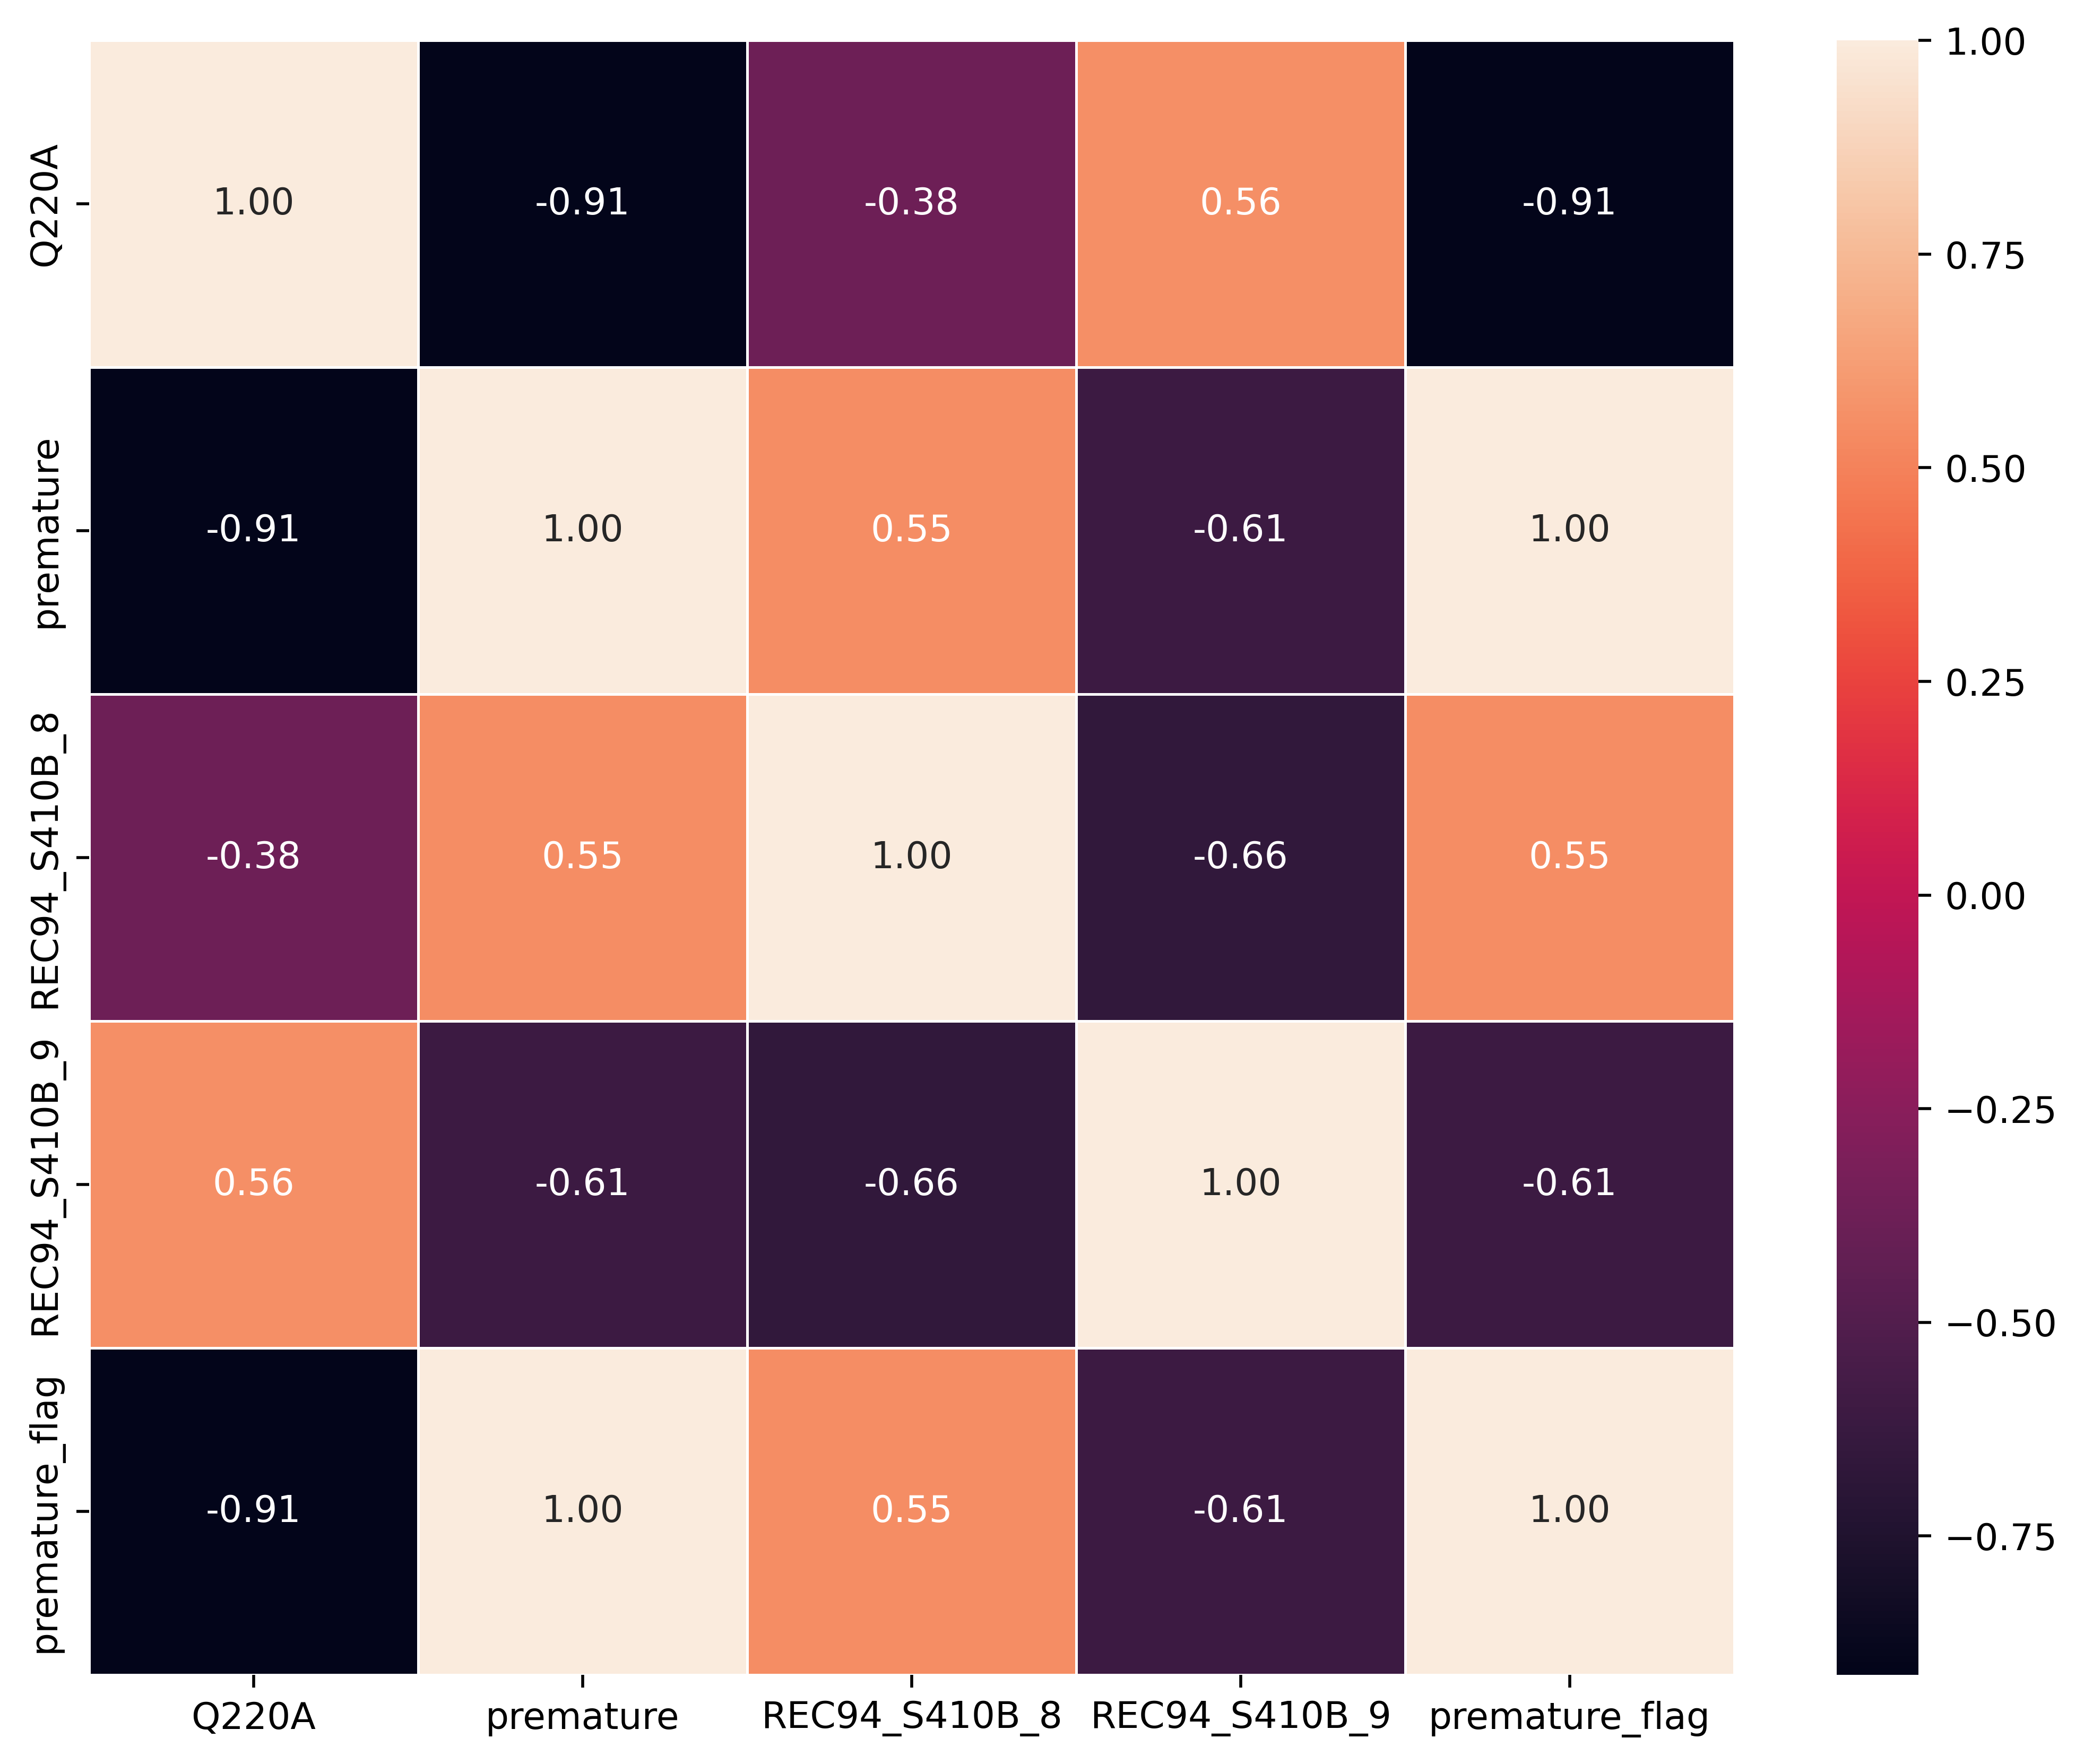

In [36]:
corr = tem_data_train[feature_corr].corr(method = 'pearson')
plt.figure(figsize=(10,8), dpi =500)
sns.heatmap(corr,annot=True,fmt=".2f", linewidth=.5)
plt.show()

In [37]:
remove_columns =['HHID',
                 'CASEID',
                   'BIDX',
                     'Q220A',
                       'premature', 
                       'CASEID_HHID',
                       'REC94_S410B_8',
                         'REC94_S410B_9']
data_train =data_train.drop(columns=remove_columns)
data_train.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 16983 entries, 0 to 18334
Data columns (total 329 columns):
 #    Column             Non-Null Count  Dtype  
---   ------             --------------  -----  
 0    premature_flag     16983 non-null  int64  
 1    REC91_SREGION      16983 non-null  float64
 2    REC91_S108N        16983 non-null  float64
 3    REC91_S119         16983 non-null  float64
 4    REC91_S119D        16983 non-null  float64
 5    REC91_S704N        16983 non-null  float64
 6    REC91_S816W        16983 non-null  int64  
 7    REC91_S816G        16983 non-null  int64  
 8    REC91_S816B        16983 non-null  int64  
 9    REC91_S816AL       16983 non-null  int64  
 10   REC91_S500B        16983 non-null  int64  
 11   RE516171_V704      16983 non-null  float64
 12   RE516171_V715      16983 non-null  float64
 13   RE516171_V501      16983 non-null  float64
 14   RE516171_V716      16983 non-null  float64
 15   RE516171_V511      16983 non-null  float64
 16   RE51617

In [38]:
data_train['premature_flag'].value_counts()

premature_flag
0    13686
1     3297
Name: count, dtype: int64

In [39]:
df_train_test , df_holdout = train_test_split(data_train, test_size=0.1, random_state=42)  # random_state for reproducibility

train_data, test_data, train_labels, test_labels,features = split_dataset(df_train_test, remove_columns=None, target_variable='premature_flag')

holdout_data = df_holdout[features]
holdout_labels= df_holdout['premature_flag']


Train shape: (11887, 328), Test shape: (3397, 328)
Train labels shape: (11887,), Test labels shape: (3397,)
Features used: 328


In [40]:
holdout_data.shape, holdout_labels.shape

((1699, 328), (1699,))

In [49]:
print(train_labels.value_counts(1)), 
print(test_labels.value_counts(1)), 
print(holdout_labels.value_counts(1)), 


premature_flag
0    0.806595
1    0.193405
Name: proportion, dtype: float64
premature_flag
0    0.806594
1    0.193406
Name: proportion, dtype: float64
premature_flag
0    0.799294
1    0.200706
Name: proportion, dtype: float64


(None,)

In [41]:
result = rank_models(train_data, train_labels, test_data, test_labels, holdout_data, holdout_labels)

c:\Users\linoc\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 2299, number of negative: 9588
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008579 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 938
[LightGBM] [Info] Number of data points in the train set: 11887, number of used features: 244
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.193405 -> initscore=-1.428038
[LightGBM] [Info] Start training from score -1.428038


In [43]:
result

,Model,dataset_type,Accuracy,Recall,Precision,F1 Score,KS Stat,ROC AUC,Rank
0,XGBClassifier,Test,0.8293,0.3333,0.6066,0.4303,0.4006,0.7617,1
1,XGBClassifier,Holdout,0.8175,0.3314,0.5795,0.4216,0.4066,0.7717,2
10,SVM,Test,0.7436,0.6271,0.3969,0.4861,0.4114,0.7658,3
11,SVM,Holdout,0.7375,0.6716,0.4067,0.5066,0.4342,0.7871,4
6,RandomForest,Test,0.8357,0.1857,0.8414,0.3042,0.3954,0.7547,5
7,RandomForest,Holdout,0.8258,0.1584,0.8571,0.2673,0.4193,0.7833,6
2,LogisticRegression,Test,0.7304,0.6743,0.3869,0.4917,0.4236,0.7784,7
3,LogisticRegression,Holdout,0.7251,0.7009,0.3957,0.5058,0.4493,0.7961,8
4,LightGBM,Test,0.8384,0.3120,0.6788,0.4275,0.4260,0.7803,9
5,LightGBM,Holdout,0.8258,0.3138,0.6331,0.4196,0.4334,0.7944,10


In [50]:
import xgboost as xgb
import pandas as pd
import numpy as np
from scipy.stats import ks_2samp
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score)
    
# def train_xgb_and_rank(train_data, train_labels, test_data, test_labels, holdout_data, holdout_labels):
#     """
#     Train an XGBoost model with class imbalance handling and evaluate
#     on Test and Holdout datasets using common metrics.
#     """
    
#     # Flatten label arrays if needed
#     y_train = np.ravel(train_labels)
#     y_test = np.ravel(test_labels)
#     y_holdout = np.ravel(holdout_labels)

#     # Handle imbalance automatically
#     neg, pos = np.bincount(y_train)
#     scale_pos_weight = neg / pos
#     print(f"Class imbalance ratio (scale_pos_weight): {scale_pos_weight:.2f}")
    
#     # XGBoost baseline parameters
#     model = xgb.XGBClassifier(
#         n_estimators=2000,
#         learning_rate=0.01,
#         max_depth=8,
#         min_child_weight=1,
#         subsample=0.8,
#         colsample_bytree=0.8,
#         gamma=0,
#         reg_lambda=1,
#         reg_alpha=0,
#         scale_pos_weight=scale_pos_weight,
#         objective='binary:logistic',
#         eval_metric='auc',
#         random_state=123,
#         n_jobs=-1,
#         use_label_encoder=False
#     )

#     # Train model
#     model.fit(train_data, y_train)

#     # Function to compute metrics
#     def evaluate(data, labels, dataset_type):
#         preds = model.predict(data)
#         probs = model.predict_proba(data)[:, 1]
        
#         accuracy = accuracy_score(labels, preds)
#         recall = recall_score(labels, preds)
#         precision = precision_score(labels, preds)
#         f1 = f1_score(labels, preds)
#         roc_auc = roc_auc_score(labels, probs)

#         # KS statistic
#         positive_probs = probs[labels == 1]
#         negative_probs = probs[labels == 0]
#         ks_stat = ks_2samp(positive_probs, negative_probs).statistic

#         return {
#             'Model': 'XGBClassifier',
#             'dataset_type': dataset_type,
#             'Accuracy': accuracy,
#             'Recall': recall,
#             'Precision': precision,
#             'F1 Score': f1,
#             'KS Stat': ks_stat,
#             'ROC AUC': roc_auc
#         }

#     # Evaluate on Test and Holdout
#     results = []
#     results.append(evaluate(test_data, y_test, 'Test'))
#     results.append(evaluate(holdout_data, y_holdout, 'Holdout'))
    
#     # Format and rank
#     results_df = pd.DataFrame(results)
#     results_df['Rank'] = range(1, len(results_df) + 1)
#     results_df = results_df.round(4)
    
#     return model, results_df


from sklearn.model_selection import GridSearchCV
import xgboost as xgb
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score
)

def train_xgb_gridsearch_and_rank(train_data, train_labels, test_data, test_labels, holdout_data, holdout_labels):
    """
    Performs GridSearchCV tuning for XGBClassifier, fits the best model,
    and evaluates it on Test and Holdout datasets.
    Returns both the trained model and a metrics DataFrame.
    """

    # Convert labels to 1D array
    y_train = np.ravel(train_labels)
    y_test = np.ravel(test_labels)
    y_holdout = np.ravel(holdout_labels)

    # Handle imbalance
    neg, pos = np.bincount(y_train)
    scale_pos_weight = neg / pos
    print(f"Class imbalance ratio (scale_pos_weight): {scale_pos_weight:.2f}")

    # Base model
    xgb_model = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        random_state=123,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight,
        use_label_encoder=False
    )

    # Parameter grid (customize as needed)
    param_grid = {
        'n_estimators': [300,350,400],
        'max_depth': [ 3,6,9],
        'learning_rate': [0.01],
        'subsample': [0.8],
        'colsample_bytree': [0.8],
        'min_child_weight': [1],
        'gamma': [0]
    }

    # GridSearchCV setup
    grid_search = GridSearchCV(
        estimator=xgb_model,
        param_grid=param_grid,
        scoring='roc_auc',
        cv=3,
        verbose=2,
        n_jobs=-1
    )

    # Run grid search
    grid_search.fit(train_data, y_train)
    best_params = grid_search.best_params_
    print("✅ Best Parameters Found:")
    for k, v in best_params.items():
        print(f"   {k}: {v}")
    print(f"🏆 Best CV ROC-AUC: {grid_search.best_score_:.4f}")

    # Retrain best model on full training set
    best_model = grid_search.best_estimator_
    best_model.fit(train_data, y_train)

    # Helper to evaluate metrics
    def evaluate(model, X, y, dataset_type):
        preds = model.predict(X)
        probs = model.predict_proba(X)[:, 1]

        accuracy = accuracy_score(y, preds)
        recall = recall_score(y, preds)
        precision = precision_score(y, preds)
        f1 = f1_score(y, preds)
        roc_auc = roc_auc_score(y, probs)

        # KS statistic
        positive_probs = probs[y == 1]
        negative_probs = probs[y == 0]
        ks_stat = ks_2samp(positive_probs, negative_probs).statistic

        return {
            'Model': 'XGBClassifier (GridSearch)',
            'dataset_type': dataset_type,
            'Accuracy': accuracy,
            'Recall': recall,
            'Precision': precision,
            'F1 Score': f1,
            'KS Stat': ks_stat,
            'ROC AUC': roc_auc
        }

    # Evaluate on Test & Holdout
    results = [
        evaluate(best_model, test_data, y_test, 'Test'),
        evaluate(best_model, holdout_data, y_holdout, 'Holdout')
    ]

    # Format results table
    results_df = pd.DataFrame(results)
    results_df['Rank'] = range(1, len(results_df) + 1)
    results_df = results_df.round(4)

    return best_model, results_df, best_params


In [51]:
model_1, results_df_1, best_params_1 =  train_xgb_gridsearch_and_rank(train_data, train_labels, test_data, test_labels, holdout_data, holdout_labels)
results_df_1

Class imbalance ratio (scale_pos_weight): 4.17
Fitting 3 folds for each of 9 candidates, totalling 27 fits


c:\Users\linoc\AppData\Local\Programs\Python\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [16:05:27] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


✅ Best Parameters Found:
   colsample_bytree: 0.8
   gamma: 0
   learning_rate: 0.01
   max_depth: 6
   min_child_weight: 1
   n_estimators: 400
   subsample: 0.8
🏆 Best CV ROC-AUC: 0.7963


c:\Users\linoc\AppData\Local\Programs\Python\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [16:05:31] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


,Model,dataset_type,Accuracy,Recall,Precision,F1 Score,KS Stat,ROC AUC,Rank
0,XGBClassifier (GridSearch),Test,0.7548,0.6484,0.4144,0.5056,0.4423,0.7891,1
1,XGBClassifier (GridSearch),Holdout,0.7487,0.6452,0.4183,0.5075,0.4419,0.8059,2


c:\Users\linoc\OneDrive\Encoder\03_partos\02_scripts\Premature_model\scripts\modeling.py:236: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  


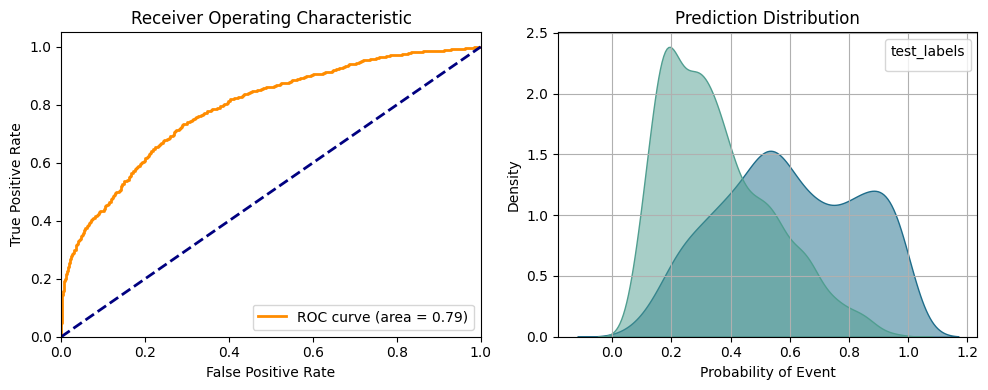

In [56]:
plot_roc_curve_from_df(model_1, test_labels, test_data, 5)